# ***Image generation of FASHION-MNIST via β-VAE***

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

Loading FAHSION MNIST dataset

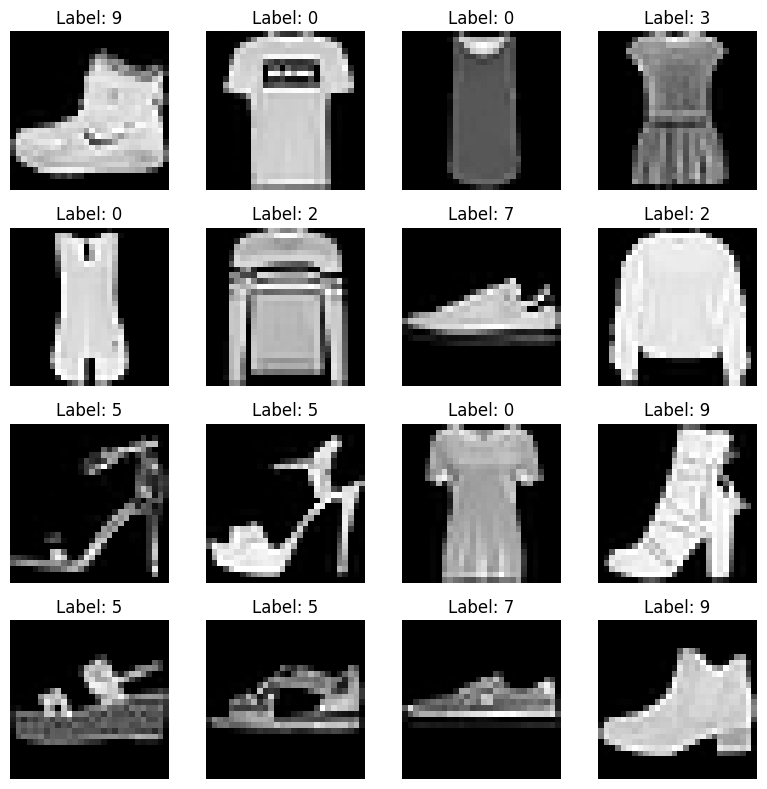

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load the dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Create a subplot with 4x4 grid
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

# Loop through each subplot and plot an image
for i in range(4):
    for j in range(4):
        image, label = train_dataset[i * 4 + j]  # Get image and label
        image_numpy = image.numpy().squeeze()    # Convert image tensor to numpy array
        axs[i, j].imshow(image_numpy, cmap='gray')  # Plot the image
        axs[i, j].axis('off')  # Turn off axis
        axs[i, j].set_title(f"Label: {label}")  # Set title with label

plt.tight_layout()  # Adjust layout
plt.show()  # Show plot

for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break

#**Theory**

**Encoder and decoder of VAE are decoded as follows.**

- Encoder (Gaussian distribution)：$$q_{\phi}({\bf z}|{\bf x}) = {\mathcal N}({\bf z}| \mu,\sigma^2{\bf I}), 　s.t.　\mu=g^{\mu}_{\phi}({\bf x}), \sigma=g^{\sigma}_{\phi}({\bf x}). $$

- Decoder (Bernoulli distribution)：$$p_{\theta}({\bf x}|{\bf z}) = Ber({\bf x}| \lambda), 　s.t.　\lambda=f_{\theta}({\bf z}).$$

<br>



**ELBO (Evidence Lower BOund) is represented like below.**  The first and the second term are corresponding to (minus) reconstruction loss and KL divergence, respectively. For the implementation of β-VAE, the coefficient β(>1) in the regularisation term of the objective function is needed in order to make the model more disentangled.





$$
 {\mathcal L}({\bf x};{\bf \theta},{\bf \phi}) = \mathbb{E}_{q_{\phi}({\bf z}|{\bf x})}[\log p_\theta({\bf x}|{\bf z})] -\beta D_{KL}[q_{\phi}({\bf z}|{\bf x})||p_{\theta}({\bf z})]
 $$  

#**MODEL**

In [ ]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(BetaVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder Network
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1),  # Output: (batch, 8, 14, 14)
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1),  # Output: (batch, 16, 7, 7)
            nn.ReLU(),
            nn.BatchNorm2d(16),  # Output: (batch, 16, 7, 7)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=0),  # Output: (batch, 32, 3, 3)
            nn.ReLU(),
            nn.Flatten()  # Output: (batch, 32 * 3 * 3)
        )

        self.fc_mu = nn.Linear(32 * 3 * 3, latent_dim)      # Mean
        self.fc_logvar = nn.Linear(32 * 3 * 3, latent_dim)  # Log-variance

        self.decoder_input = nn.Linear(latent_dim, 32 * 3 * 3)

        self.decoder = nn.Sequential(
            nn.ReLU(),
            nn.Unflatten(1, (32, 3, 3)),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=0),  # Output: (batch, 16, 7, 7)
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.ConvTranspose2d(in_channels=16, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: (batch, 8, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=8, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: (batch, 1, 28, 28)
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Standard deviation
        eps = torch.randn_like(std)    # Random noise ~ N(0, 1)
        return mu + std * eps

    def forward(self, x):
        # Pass through Encoder
        x = self.encoder(x)

        # Compute mean and log-variance
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        # Sample latent vector z using reparameterization trick
        z = self.reparameterize(mu, logvar)

        # Pass through Decoder
        x = self.decoder_input(z)
        x = self.decoder(x)

        return x, mu, logvar


In [ ]:
# Loss = Reconstruction Loss + beta * KL Divergence
def beta_loss(recon_x, x, mu, logvar, beta=1):

    # Reconstruction Loss (Binary Cross-Entropy for images scaled between 0 and 1)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence: KL(N(mu, sigma) || N(0, 1))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss
    loss = recon_loss + beta * kl_div
    return loss


# **TRAINING**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 10
beta = 5

model = BetaVAE(latent_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        recon_data, mu, logvar = model(data)

        loss = beta_loss(recon_data, data, mu, logvar, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}] Loss: {loss.item() / len(data):.4f}")

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

print("Training complete!")


Epoch [1/10] Batch [0] Loss: 594.1287
Epoch [1/10] Batch [100] Loss: 374.2755
Epoch [1/10] Batch [200] Loss: 351.4487
Epoch [1/10] Batch [300] Loss: 307.3338
Epoch [1/10] Batch [400] Loss: 311.0790
Epoch [1/10] Batch [500] Loss: 291.5477
Epoch [1/10] Batch [600] Loss: 300.9761
Epoch [1/10] Batch [700] Loss: 300.7619
Epoch [1/10] Batch [800] Loss: 311.6586
Epoch [1/10] Batch [900] Loss: 306.5093
Epoch [1/10] Average Loss: 322.7628
Epoch [2/10] Batch [0] Loss: 278.6328
Epoch [2/10] Batch [100] Loss: 287.2158
Epoch [2/10] Batch [200] Loss: 281.9623
Epoch [2/10] Batch [300] Loss: 272.1302
Epoch [2/10] Batch [400] Loss: 277.7690
Epoch [2/10] Batch [500] Loss: 284.2694
Epoch [2/10] Batch [600] Loss: 279.4708
Epoch [2/10] Batch [700] Loss: 308.6562
Epoch [2/10] Batch [800] Loss: 281.6472
Epoch [2/10] Batch [900] Loss: 294.3419
Epoch [2/10] Average Loss: 288.1416
Epoch [3/10] Batch [0] Loss: 278.0049
Epoch [3/10] Batch [100] Loss: 285.1467
Epoch [3/10] Batch [200] Loss: 280.3941
Epoch [3/10] B

**Visualization of reconstructed image**

Original image

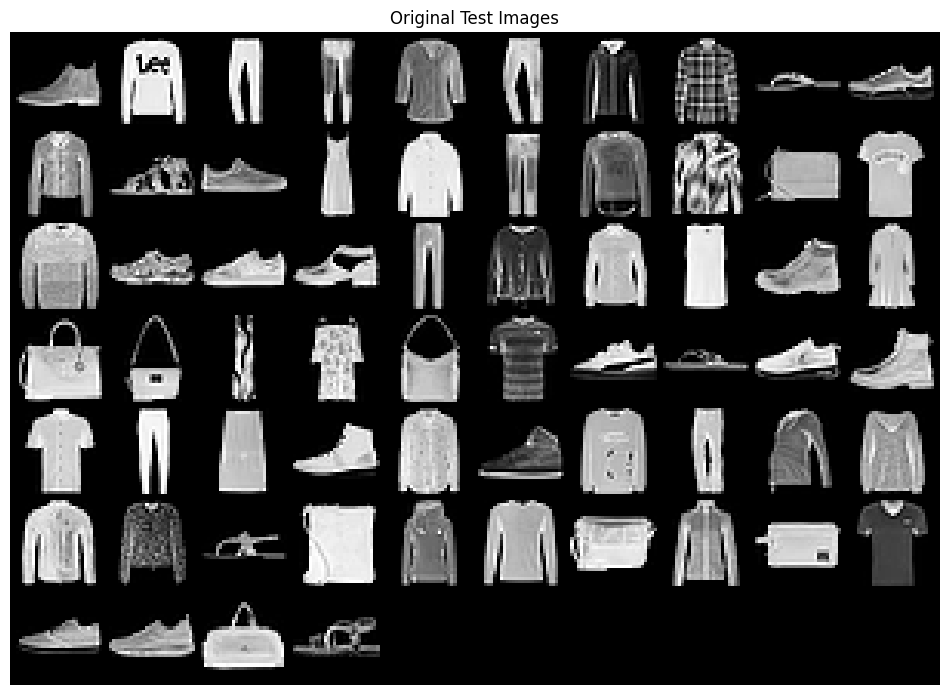

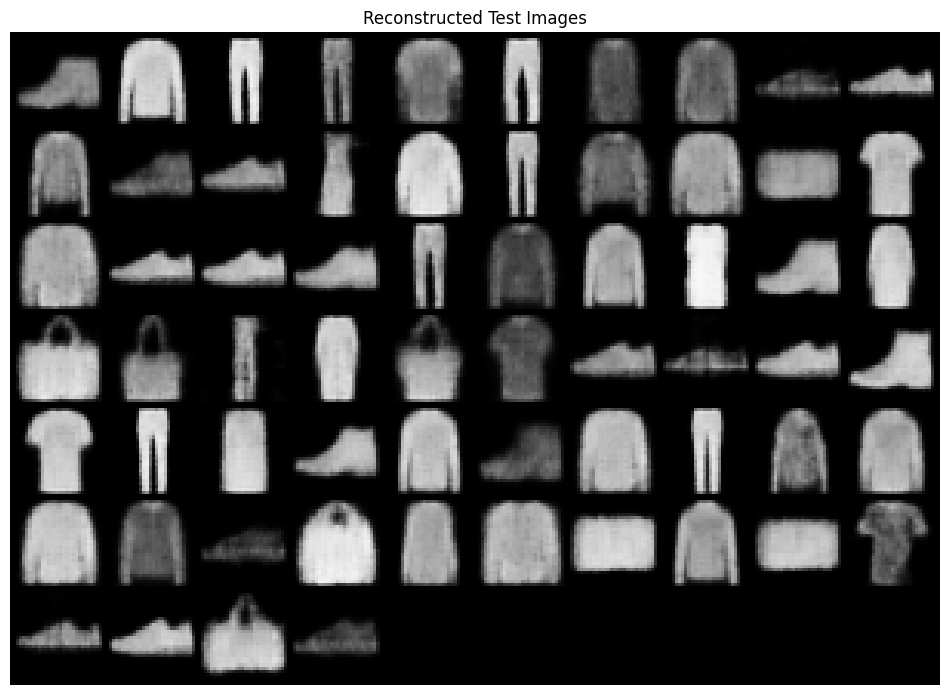

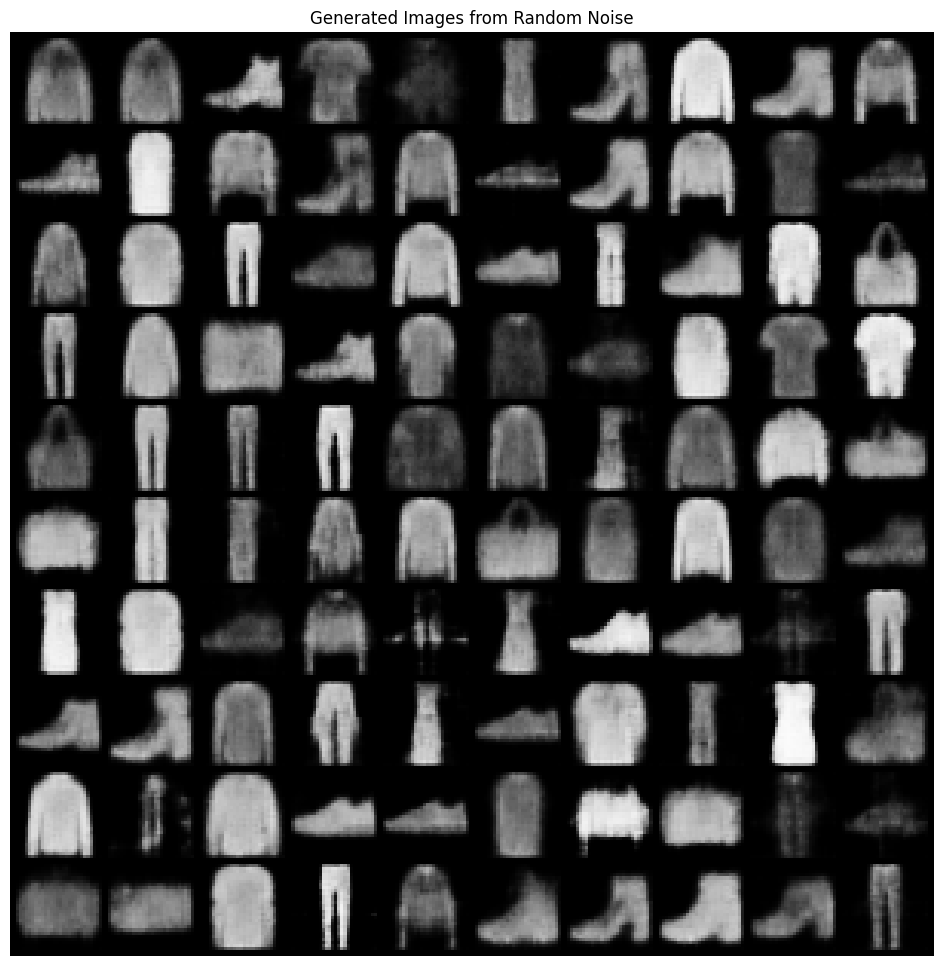

In [ ]:
from torchvision.utils import make_grid

model.eval()
latent_dim = 10

def show_images(images, title):
    images = images.cpu().detach()
    grid = make_grid(images, nrow=10)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()


with torch.no_grad():
    # Reconstruct
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    reconstructed, _, _ = model(test_images)
    # Generate
    z = torch.randn(100, latent_dim).to(device)
    generated_images = model.decoder(model.decoder_input(z))


show_images(test_images, "Original Test Images")
show_images(reconstructed, "Reconstructed Test Images")
show_images(generated_images, "Generated Images from Random Noise")

In [ ]:
pip install torchmetrics torchvision

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install torchmetrics[image]


Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.


Random sampling from latent variable

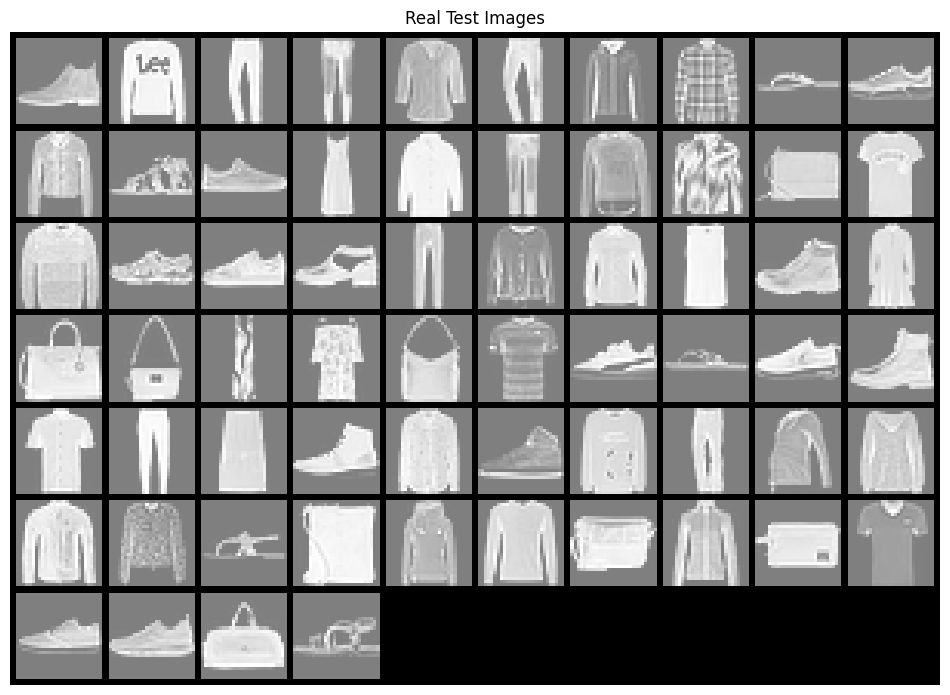

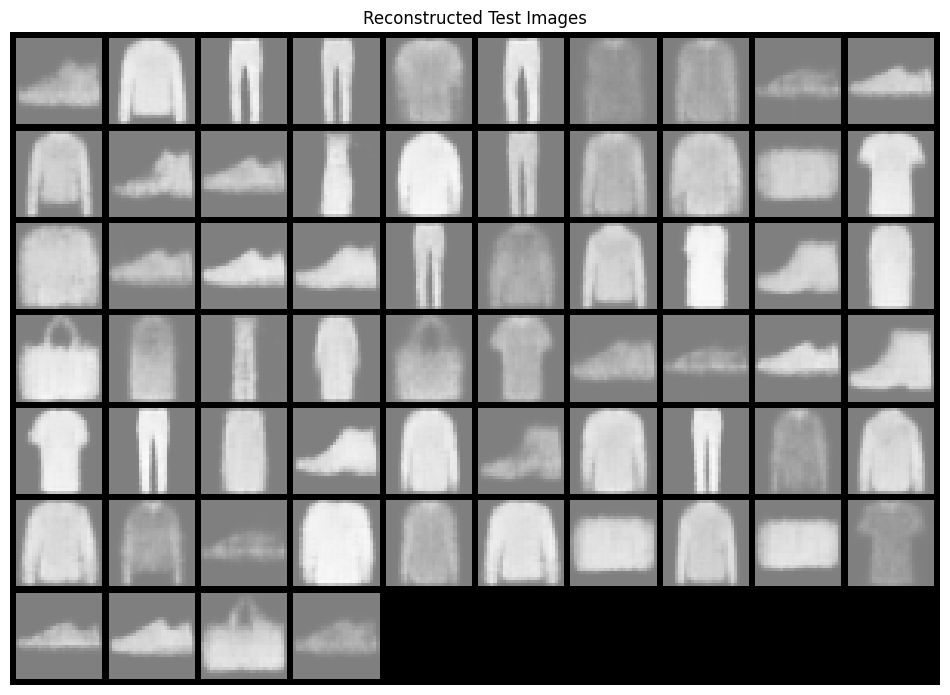

FID between real and reconstructed images: 0.1552


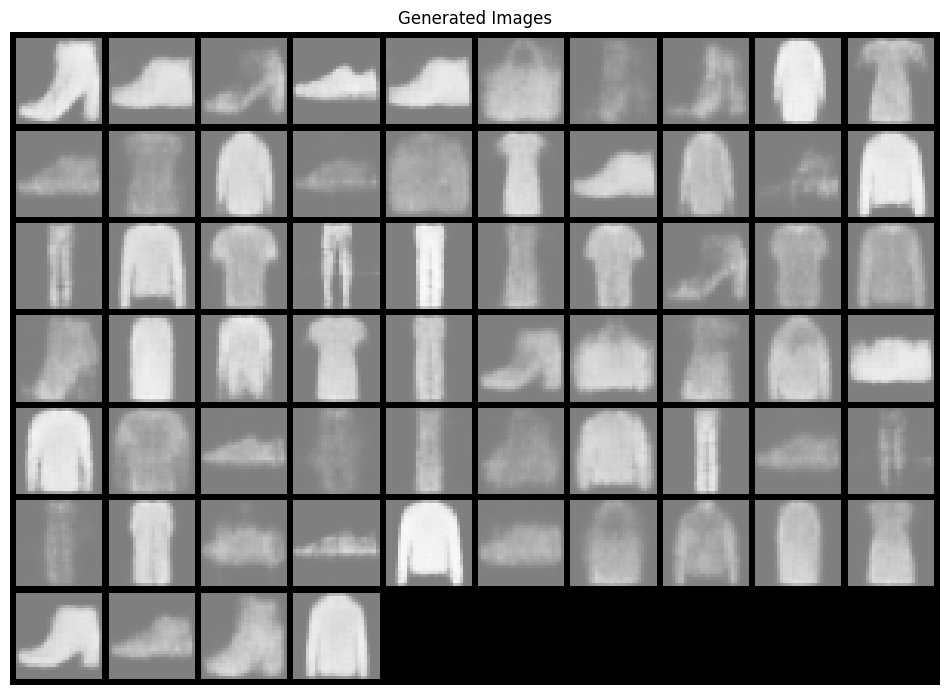

FID between real and generated images: 0.2676


In [ ]:
def preprocess_images(images):
    images = (images + 1.0) / 2.0
    images = images.clamp(0, 1)
    images = (images * 255).to(torch.uint8)
    images = images.repeat(1, 3, 1, 1)
    return images

# 1. Reconstruct Test Images and Calculate FID
fid.reset()
real_images_list, recon_images_list = [], []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        # Reconstruct images
        recon_data, mu, logvar = model(data)

        # Preprocess images to uint8
        real_images = preprocess_images(data)
        recon_images = preprocess_images(recon_data)

        # Add real and reconstructed images to FID
        fid.update(real_images, real=True)
        fid.update(recon_images, real=False)

        real_images_list.append(real_images)
        recon_images_list.append(recon_images)
        if len(real_images_list) == 1:
            show_images(real_images.float() / 255, "Real Test Images")
            show_images(recon_images.float() / 255, "Reconstructed Test Images")
            break

fid_value_reconstructed = fid.compute()
print(f"FID between real and reconstructed images: {fid_value_reconstructed.item():.4f}")

# 2. Generate Random Images and Calculate FID
fid.reset()
generated_images_list = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        real_images = preprocess_images(data)
        z = torch.randn(64, latent_dim).to(device)

        generated_data = model.decoder(model.decoder_input(z))
        generated_images = preprocess_images(generated_data)

        fid.update(real_images, real=True)
        fid.update(generated_images, real=False)
        generated_images_list.append(generated_images)

        if len(generated_images_list) == 1:
            show_images(generated_images.float() / 255, "Generated Images")
            break

fid_value_generated = fid.compute()
print(f"FID between real and generated images: {fid_value_generated.item():.4f}")


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 10
beta = 1

model = BetaVAE(latent_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        recon_data, mu, logvar = model(data)

        loss = beta_loss(recon_data, data, mu, logvar, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}] Loss: {loss.item() / len(data):.4f}")

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

print("Training complete!")


Epoch [1/10] Batch [0] Loss: 540.6160
Epoch [1/10] Batch [100] Loss: 329.0016
Epoch [1/10] Batch [200] Loss: 275.1647
Epoch [1/10] Batch [300] Loss: 257.6331
Epoch [1/10] Batch [400] Loss: 262.6176
Epoch [1/10] Batch [500] Loss: 264.8311
Epoch [1/10] Batch [600] Loss: 251.6970
Epoch [1/10] Batch [700] Loss: 265.2239
Epoch [1/10] Batch [800] Loss: 266.4159
Epoch [1/10] Batch [900] Loss: 259.5813
Epoch [1/10] Average Loss: 282.5676
Epoch [2/10] Batch [0] Loss: 251.8825
Epoch [2/10] Batch [100] Loss: 252.6948
Epoch [2/10] Batch [200] Loss: 252.7210
Epoch [2/10] Batch [300] Loss: 253.0016
Epoch [2/10] Batch [400] Loss: 265.9972
Epoch [2/10] Batch [500] Loss: 259.0190
Epoch [2/10] Batch [600] Loss: 247.5013
Epoch [2/10] Batch [700] Loss: 263.3245
Epoch [2/10] Batch [800] Loss: 257.2948
Epoch [2/10] Batch [900] Loss: 235.9764
Epoch [2/10] Average Loss: 253.5154
Epoch [3/10] Batch [0] Loss: 244.4613
Epoch [3/10] Batch [100] Loss: 255.9624
Epoch [3/10] Batch [200] Loss: 267.2352
Epoch [3/10] B

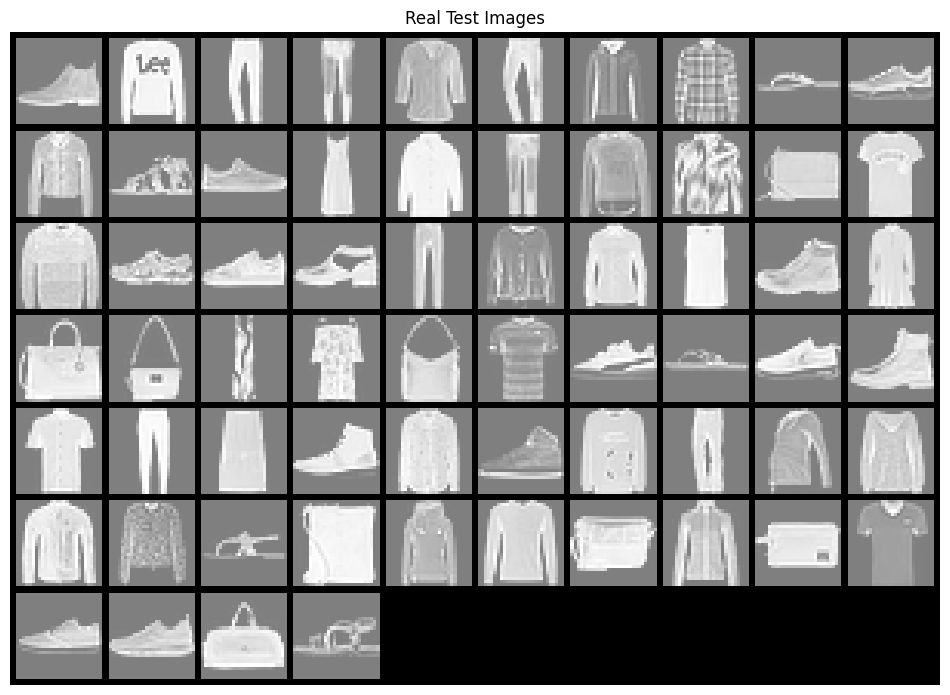

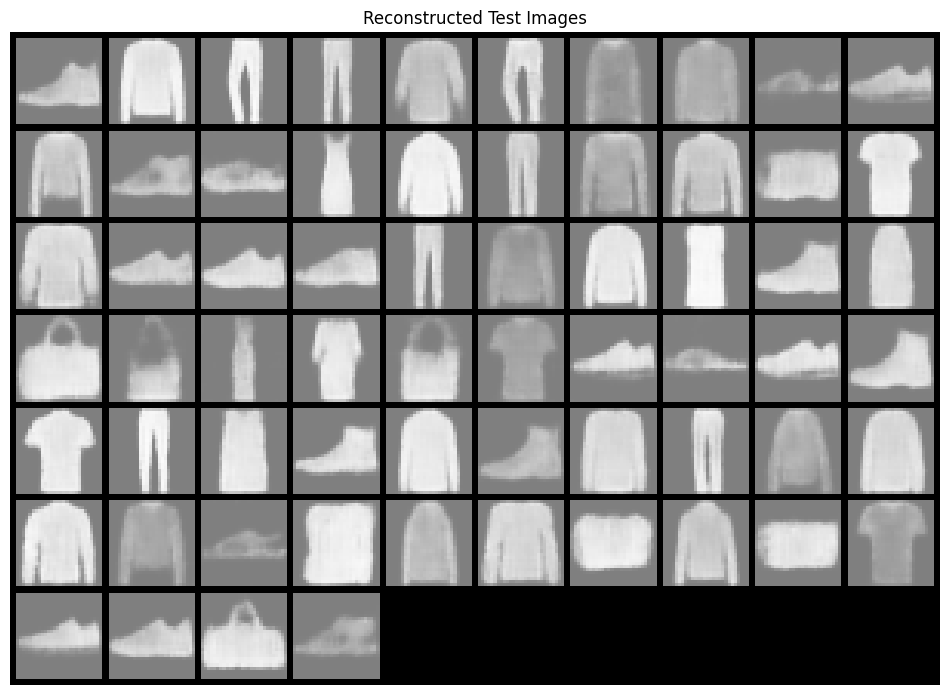

FID between real and reconstructed images: 0.1162


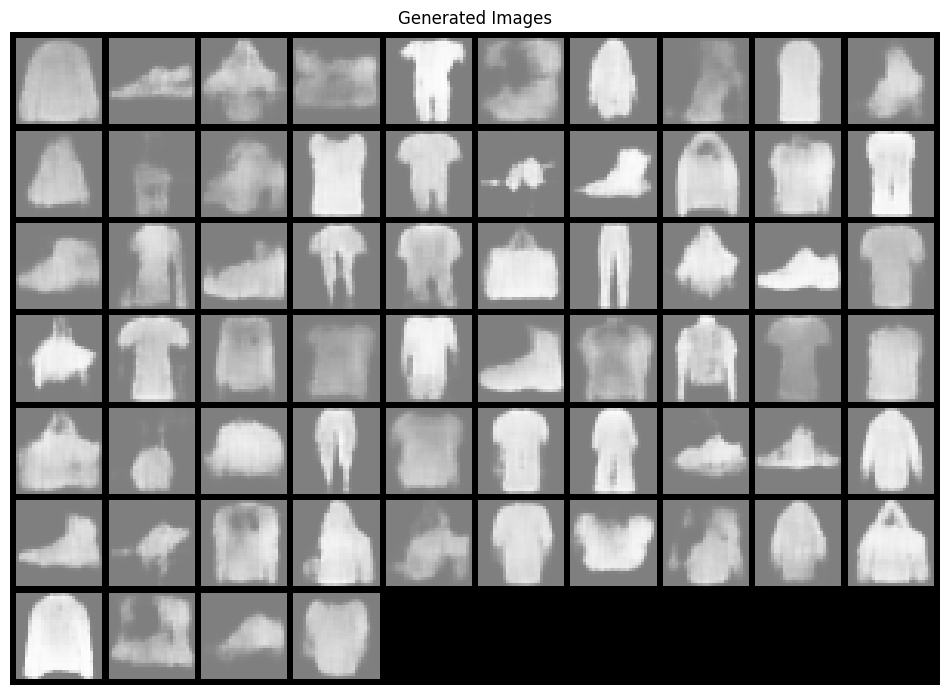

FID between real and generated images: 0.1549


In [ ]:
def preprocess_images(images):
    images = (images + 1.0) / 2.0
    images = images.clamp(0, 1)
    images = (images * 255).to(torch.uint8)
    images = images.repeat(1, 3, 1, 1)
    return images

# 1. Reconstruct Test Images and Calculate FID
fid.reset()
real_images_list, recon_images_list = [], []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        # Reconstruct images
        recon_data, mu, logvar = model(data)

        # Preprocess images to uint8
        real_images = preprocess_images(data)
        recon_images = preprocess_images(recon_data)

        # Add real and reconstructed images to FID
        fid.update(real_images, real=True)
        fid.update(recon_images, real=False)

        real_images_list.append(real_images)
        recon_images_list.append(recon_images)
        if len(real_images_list) == 1:
            show_images(real_images.float() / 255, "Real Test Images")
            show_images(recon_images.float() / 255, "Reconstructed Test Images")
            break

fid_value_reconstructed = fid.compute()
print(f"FID between real and reconstructed images: {fid_value_reconstructed.item():.4f}")

# 2. Generate Random Images and Calculate FID
fid.reset()
generated_images_list = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        real_images = preprocess_images(data)
        z = torch.randn(64, latent_dim).to(device)

        generated_data = model.decoder(model.decoder_input(z))
        generated_images = preprocess_images(generated_data)

        fid.update(real_images, real=True)
        fid.update(generated_images, real=False)
        generated_images_list.append(generated_images)

        if len(generated_images_list) == 1:
            show_images(generated_images.float() / 255, "Generated Images")
            break

fid_value_generated = fid.compute()
print(f"FID between real and generated images: {fid_value_generated.item():.4f}")


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 10
beta = 20

model = BetaVAE(latent_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        recon_data, mu, logvar = model(data)

        loss = beta_loss(recon_data, data, mu, logvar, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}] Loss: {loss.item() / len(data):.4f}")

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

print("Training complete!")


Epoch [1/10] Batch [0] Loss: 532.2787
Epoch [1/10] Batch [100] Loss: 403.9530
Epoch [1/10] Batch [200] Loss: 367.6573
Epoch [1/10] Batch [300] Loss: 368.1808
Epoch [1/10] Batch [400] Loss: 373.7493
Epoch [1/10] Batch [500] Loss: 351.1256
Epoch [1/10] Batch [600] Loss: 327.2340
Epoch [1/10] Batch [700] Loss: 347.5777
Epoch [1/10] Batch [800] Loss: 346.3085
Epoch [1/10] Batch [900] Loss: 332.4868
Epoch [1/10] Average Loss: 366.9459
Epoch [2/10] Batch [0] Loss: 336.9421
Epoch [2/10] Batch [100] Loss: 341.9602
Epoch [2/10] Batch [200] Loss: 355.6232
Epoch [2/10] Batch [300] Loss: 343.2705
Epoch [2/10] Batch [400] Loss: 333.0289
Epoch [2/10] Batch [500] Loss: 332.0999
Epoch [2/10] Batch [600] Loss: 338.5062
Epoch [2/10] Batch [700] Loss: 342.0613
Epoch [2/10] Batch [800] Loss: 322.8531
Epoch [2/10] Batch [900] Loss: 354.4310
Epoch [2/10] Average Loss: 337.7718
Epoch [3/10] Batch [0] Loss: 328.8991
Epoch [3/10] Batch [100] Loss: 347.0323
Epoch [3/10] Batch [200] Loss: 325.8848
Epoch [3/10] B

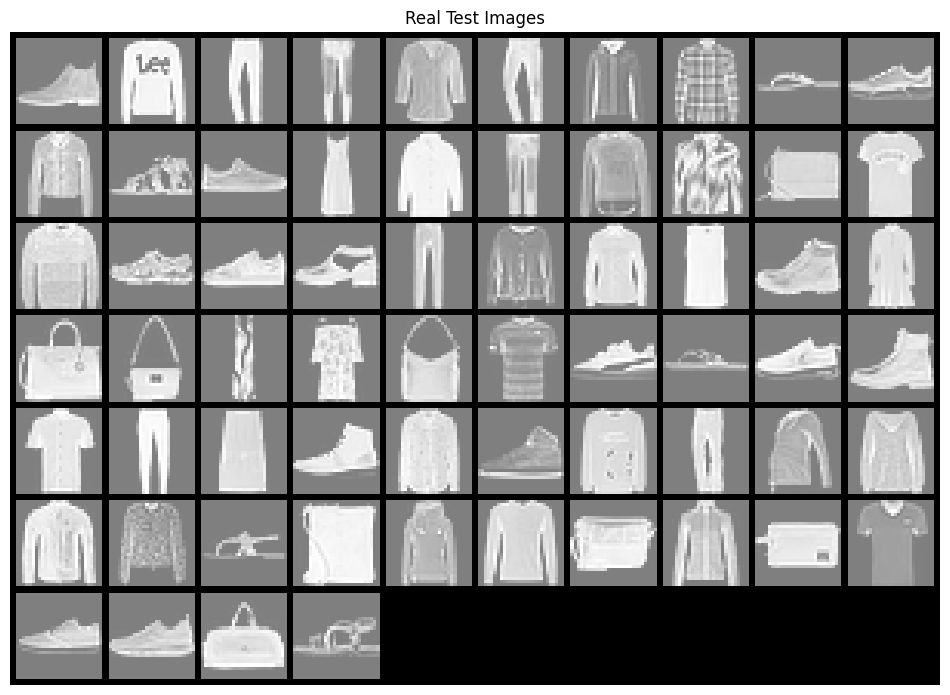

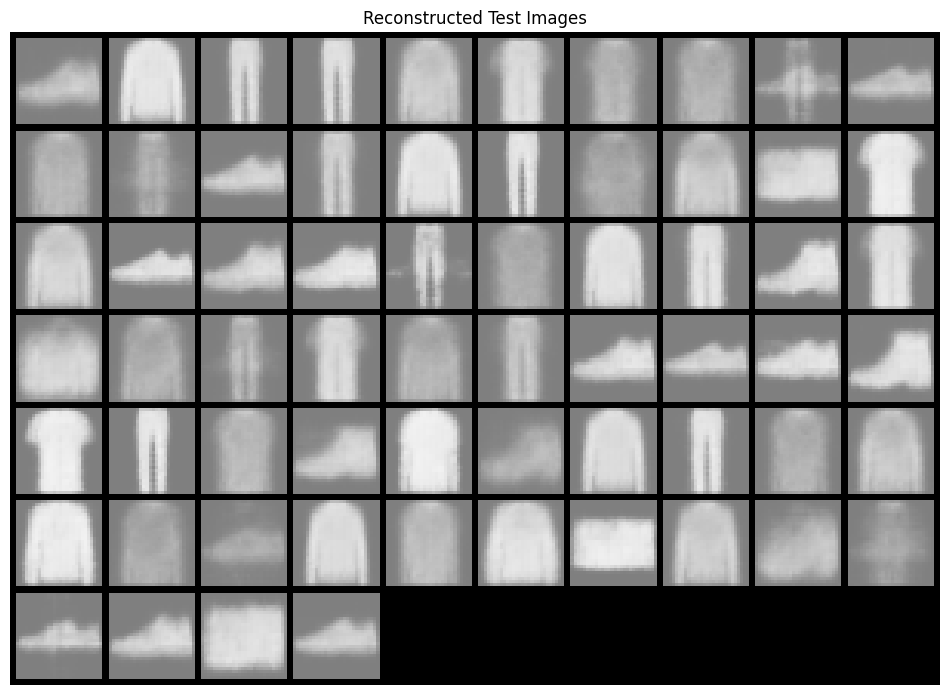

FID between real and reconstructed images: 0.2237


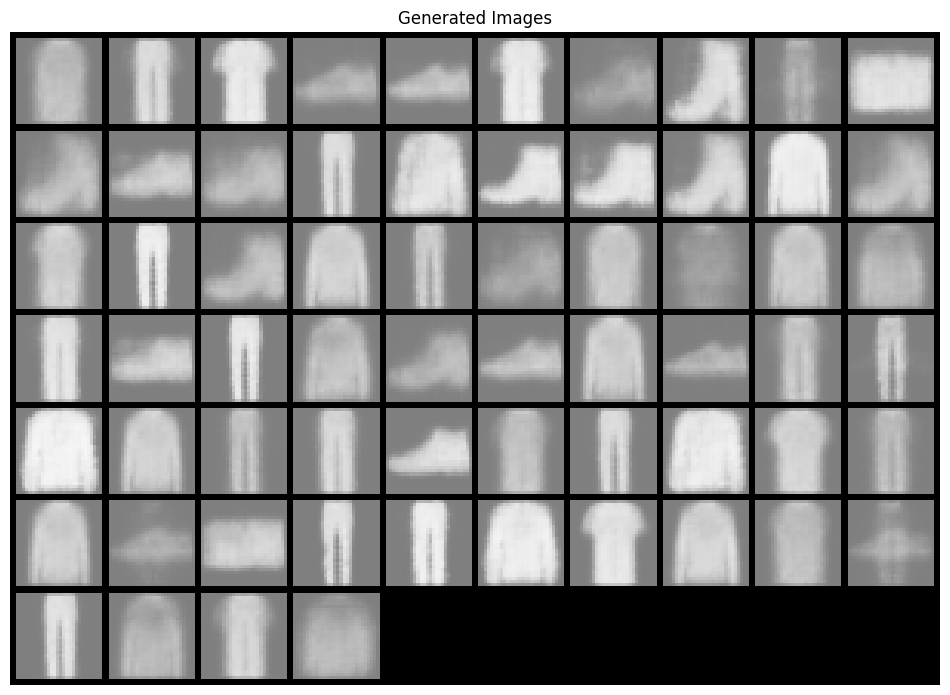

FID between real and generated images: 0.2131


In [ ]:
def preprocess_images(images):
    images = (images + 1.0) / 2.0
    images = images.clamp(0, 1)
    images = (images * 255).to(torch.uint8)
    images = images.repeat(1, 3, 1, 1)
    return images

# 1. Reconstruct Test Images and Calculate FID
fid.reset()
real_images_list, recon_images_list = [], []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        # Reconstruct images
        recon_data, mu, logvar = model(data)

        # Preprocess images to uint8
        real_images = preprocess_images(data)
        recon_images = preprocess_images(recon_data)

        # Add real and reconstructed images to FID
        fid.update(real_images, real=True)
        fid.update(recon_images, real=False)

        real_images_list.append(real_images)
        recon_images_list.append(recon_images)
        if len(real_images_list) == 1:
            show_images(real_images.float() / 255, "Real Test Images")
            show_images(recon_images.float() / 255, "Reconstructed Test Images")
            break

fid_value_reconstructed = fid.compute()
print(f"FID between real and reconstructed images: {fid_value_reconstructed.item():.4f}")

# 2. Generate Random Images and Calculate FID
fid.reset()
generated_images_list = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        real_images = preprocess_images(data)
        z = torch.randn(64, latent_dim).to(device)

        generated_data = model.decoder(model.decoder_input(z))
        generated_images = preprocess_images(generated_data)

        fid.update(real_images, real=True)
        fid.update(generated_images, real=False)
        generated_images_list.append(generated_images)

        if len(generated_images_list) == 1:
            show_images(generated_images.float() / 255, "Generated Images")
            break

fid_value_generated = fid.compute()
print(f"FID between real and generated images: {fid_value_generated.item():.4f}")


# پاسخ سوال‌های تئوری تمرین


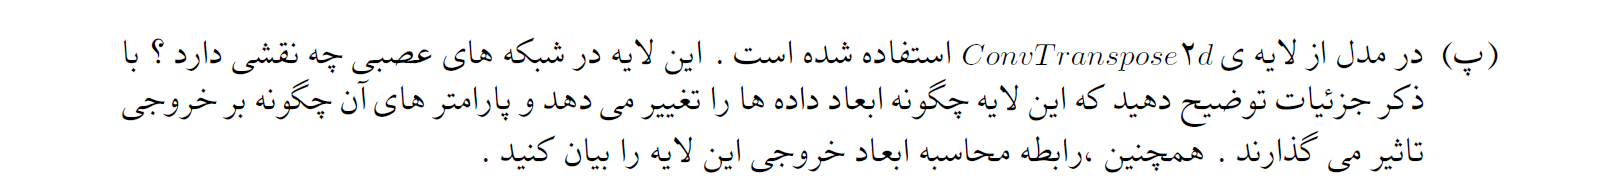


لایه‌ی **`ConvTranspose2d`**
 در شبکه‌های عصبی کانولوشنی (به‌ویژه در معماری‌های مانند **VAE** یا Autoencoders) به‌عنوان **لایه‌ی "کانولوشن معکوس"** یا **"Deconvolution"** شناخته می‌شود. نقش این لایه افزایش ابعاد فضایی (Spatial Dimensions) یک تصویر یا ویژگی‌ها است. به عبارت دیگر، این لایه برخلاف کانولوشن معمولی که ابعاد را کاهش می‌دهد (Downsampling)، عمل می‌کند و ابعاد را افزایش می‌دهد (Upsampling).

در مورد کاربرد این لایه در **VAE (Variational Autoencoder):**
- در **Decoder**، هدف بازسازی تصویری با ابعاد اولیه از یک بردار فشرده‌شده (Latent Vector) است.
- لایه‌های **ConvTranspose2d** به Decoder اجازه می‌دهند که با افزایش تدریجی ابعاد فضایی ویژگی‌ها، تصویر نهایی را بازسازی کند.

### چگونگی عملکرد
1. **افزایش ابعاد فضایی:**
   - این لایه یک عملیات کانولوشن "برعکس" را انجام می‌دهد که در آن از **Kernel** برای گسترش (توزیع) اطلاعات در فضایی بزرگ‌تر استفاده می‌شود.
   - برای مثال، اگر ورودی $4 \times 4$ باشد و این لایه با Kernel سایز $3 \times 3$ و Stride برابر با 2 اعمال شود، خروجی $8 \times 8$ خواهد بود.

ابعاد خروجی در این لایه توسط فرمول زیر محاسبه می‌شود:

$$
H_{\text{out}} = (H_{\text{in}} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel size} + \text{output padding}
$$
$$
W_{\text{out}} = (W_{\text{in}} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel size} + \text{output padding}
$$

**اجزای فرمول:**
- $ H_{\text{in}} $, $ W_{\text{in}} $: ارتفاع و عرض ورودی.
- **stride**: میزان جابجایی فیلتر در هر مرحله.
- **padding**: تعداد صفرهایی که به لبه‌های داده‌ی ورودی اضافه می‌شود.
- **kernel size**: ابعاد کرنل (فیلتر).
- **output padding**: پارامتر اضافی برای کنترل دقیق ابعاد خروجی.

---

### تاثیر پارامترها بر خروجی:
1. **Kernel Size (اندازه کرنل):**  
   کرنل مشخص می‌کند که چه ابعادی از ورودی در خروجی تأثیر می‌گذارد. افزایش اندازه کرنل معمولاً باعث افزایش مقادیر خروجی می‌شود.

2. **Stride (گام حرکت):**  
   **Stride > 1** باعث افزایش سریع‌تر ابعاد خروجی می‌شود، زیرا هر گام بزرگ‌تر در فضاهای خروجی بازتر می‌شود.

3. **Padding (پدینگ):**  
   اضافه‌کردن صفر به لبه‌های داده‌ی ورودی، ابعاد خروجی را تحت کنترل نگه می‌دارد و تأثیر کرنل در حاشیه‌ها را تنظیم می‌کند.

4. **Output Padding:**  
   این پارامتر در شرایطی که نیاز به ابعاد خاصی باشد، برای جبران کوچک‌تر بودن خروجی نهایی استفاده می‌شود.

---

### مثال عددی:
فرض کنید:
- ورودی: $ 4 \times 4 $
- Kernel Size: $ 3 $
- Stride: $ 2 $
- Padding: $ 1 $
- Output Padding: $ 0 $

محاسبه خروجی:

$$
H_{\text{out}} = (4 - 1) \times 2 - 2 \times 1 + 3 + 0 = 8
$$
$$
W_{\text{out}} = 8
$$

پس خروجی لایه $ 8 \times 8 $ خواهد بود.
2. **آموزش:**
   - این لایه همانند لایه‌های کانولوشن عادی دارای وزن‌هایی است که در طول فرایند یادگیری شبکه تنظیم می‌شوند.

3. **بازسازی تصویر:**
   - لایه‌ی **ConvTranspose2d** کمک می‌کند که ویژگی‌های فشرده‌شده در مرحله‌ی Latent Space دوباره به شکل اولیه بازسازی شوند.

### تفاوت با Upsampling
در حالی که لایه‌هایی مثل **Upsample** (مانند `nn.Upsample` در PyTorch) صرفاً مقادیر را به‌صورت ساده تکرار یا درونیابی می‌کنند، **ConvTranspose2d** یاد می‌گیرد که چطور مقادیر جدید را بر اساس داده‌های ورودی تولید کند، که این امر بازسازی باکیفیت‌تر و دقیق‌تری را ممکن می‌سازد.

### مزایا در VAE
- تولید دقیق‌تر و با جزئیات بیشتر در تصاویر خروجی.
- بازسازی داده‌ها با توجه به ویژگی‌های مهم استخراج‌شده از داده‌های ورودی.


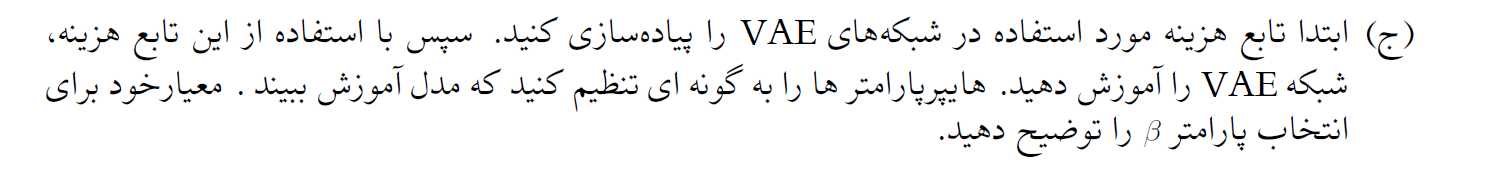

معیار من برای انتخاب
$\beta$
به صورت آزمایش و خطا بود.

همان‌طور که در کدها هم قابل مشاهده است، مقادیر
$$
\beta  =  1, 5, 10, 20
$$
را امتحان کردم.

 براساس معیار `FID`
 مقدار $1$ بهترین جواب را می‌دهد

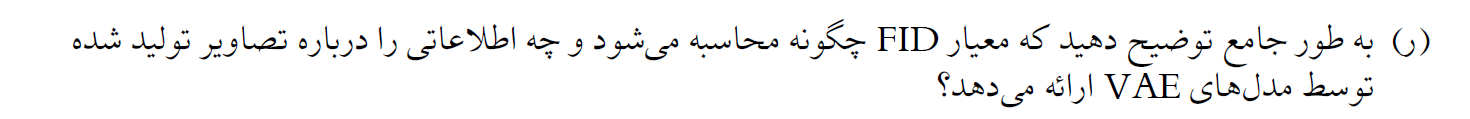


### **معرفی معیار FID**
**FID** یا **Fréchet Inception Distance** یک معیار برای ارزیابی کیفیت تصاویر تولیدشده توسط مدل‌های مولد مانند **VAE**، **GAN** و دیگر مدل‌های تولیدکننده داده‌های تصویری است. این معیار نشان می‌دهد که تصاویر تولید‌شده تا چه حد **مشابه تصاویر واقعی** هستند.

FID در مقایسه با معیارهای سنتی مانند **MSE (Mean Squared Error)** یا **PSNR**:
- توانایی بیشتری در ارزیابی **کیفیت بصری** و **جزئیات محتوایی** دارد.  
- ساختار ویژگی‌های عمیق (Deep Features) را در نظر می‌گیرد.

---

### **نحوه محاسبه FID**
برای محاسبه FID، از شبکه‌ی **Inception v3** (که یک شبکه‌ی از پیش آموزش‌دیده روی مجموعه داده ImageNet است) برای استخراج ویژگی‌های تصاویر استفاده می‌شود. محاسبات به شرح زیر است:

1. **ورود تصاویر واقعی و تولید‌شده به شبکه Inception:**
   - دو مجموعه تصویر داریم:  
     - **تصاویر واقعی (Ground Truth):** $\mathcal{X}$
     - **تصاویر تولید‌شده:** $\mathcal{G}$

2. **استخراج ویژگی‌ها:**
   - از لایه‌های میانی شبکه **Inception v3** (معمولاً خروجی لایه **Pooling** یا **Fully Connected**) ویژگی‌های تصاویر استخراج می‌شود.  
   - این ویژگی‌ها به‌صورت بردارهای میانگین و کواریانس در نظر گرفته می‌شوند.

3. **محاسبه توزیع گاوسی (Gaussian) برای هر مجموعه تصویر:**
   ویژگی‌های تصاویر به‌صورت یک **توزیع گاوسی** مدل می‌شوند.  
   برای تصاویر واقعی و تولید‌شده توزیع‌های زیر را داریم:  
   - میانگین: $\mu_{\text{real}}, \mu_{\text{gen}}$
   - ماتریس کواریانس: $\Sigma_{\text{real}}, \Sigma_{\text{gen}}$

4. **محاسبه فاصله FID بین دو توزیع:**
   فاصله FID با استفاده از فرمول **فاصله Fréchet** بین دو توزیع گاوسی محاسبه می‌شود:

   $$
   \text{FID} = ||\mu_{\text{real}} - \mu_{\text{gen}}||^2 + \text{Tr}(\Sigma_{\text{real}} + \Sigma_{\text{gen}} - 2(\Sigma_{\text{real}} \Sigma_{\text{gen}})^{\frac{1}{2}})
   $$

   - **$\mu$**: میانگین بردار ویژگی‌ها.  
   - **$\Sigma$**: ماتریس کواریانس.  
   - **Tr**: دترمینان ماتریس.

---

### **اطلاعات ارائه‌شده توسط FID:**
1. **کیفیت تصاویر تولید‌شده:**  
   هرچه مقدار FID **کمتر** باشد، تصاویر تولید‌شده **بهتر و طبیعی‌تر** هستند.  

2. **توزیع ویژگی‌ها:**  
   FID نشان می‌دهد که ویژگی‌های تصاویر تولیدشده چقدر به ویژگی‌های تصاویر واقعی نزدیک هستند.

3. **ارزیابی کلی مدل تولیدکننده:**  
   FID به‌طور غیرمستقیم **کارایی و دقت مدل** را برای تولید داده‌ها می‌سنجد.

---

### **مقایسه FID در VAE و GAN:**
- در **VAE**:  
   - تصاویر تولیدشده ممکن است جزئیات کمتری داشته باشند و **تارتر** باشند.  
   - مقدار FID ممکن است نسبت به GAN **بالاتر** باشد.  
   - این به دلیل فرض گاوسی در فضای نهفته (Latent Space) و عملکرد ساده‌تر Decoder در VAE است.

- در **GAN**:  
   - مدل‌های GAN معمولاً جزئیات دقیق‌تری تولید می‌کنند و مقدار FID کمتری دارند.

---

### **جمع‌بندی:**
معیار
FID
کیفیت تصاویر تولید‌شده توسط مدل‌های مولد مانند VAE را با توجه به **شباهت ویژگی‌ها** به تصاویر واقعی ارزیابی می‌کند. محاسبه
FID با استفاده از ویژگی‌های استخراج

شده از شبکه **Inception v3** و مدل‌سازی آن‌ها به‌عنوان **توزیع‌های گاوسی** انجام می‌شود. فرمول محاسبه FID ترکیبی از اختلاف میانگین و ماتریس‌های کواریانس این توزیع‌ها است.  

هرچه مقدار FID **کمتر** باشد، کیفیت تصاویر تولیدشده **بالاتر** و نزدیک‌تر به توزیع داده‌های واقعی است. در **VAE**، به دلیل سادگی ساختار و قیود گاوسی در فضای نهفته، مقدار FID معمولاً بیشتر از GAN است که نشان‌دهنده **کاهش دقت در جزئیات بازسازی** تصاویر است.  

برای بهبود مقدار FID در VAE:
1. استفاده از **معماری پیچیده‌تر Decoder**.
2. استفاده از مدل‌های **$\beta$-VAE** برای بهبود فضای نهفته.
3. تنظیم بهینه **تابع هزینه** برای تعادل بازسازی و منظم‌سازی.



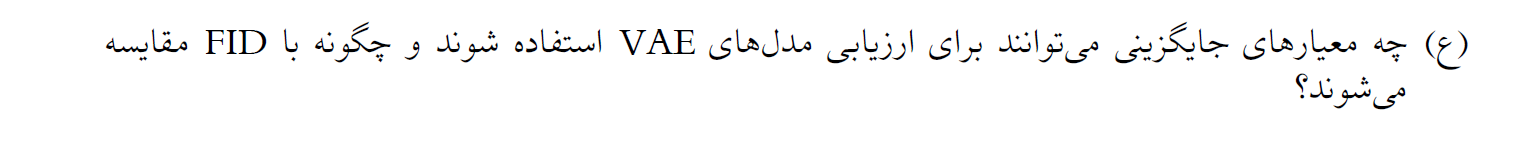

### معیارهای جایگزین برای **FID** در ارزیابی مدل‌های **VAE**

---

### **1. معیار PSNR (Peak Signal-to-Noise Ratio)**
- **توضیح:**  
   PSNR کیفیت بازسازی تصویر را از نظر **دقت پیکسل‌ها** اندازه‌گیری می‌کند. این معیار میزان تفاوت بین تصویر اصلی و تصویر بازسازی‌شده را محاسبه می‌کند.  
- **فرمول:**  
   $$
   PSNR = 10 \cdot \log_{10} \left( \frac{{MAX^2}}{{MSE}} \right)
   $$  
   که در آن **MSE** میانگین مربع خطا است و $ MAX $ بیشترین مقدار شدت پیکسل (مثلاً 255 برای تصاویر 8 بیتی).  
- **مزایا:**  
   ساده و سریع است و برای ارزیابی دقت بازسازی مناسب می‌باشد.  
- **محدودیت‌ها:**  
   توانایی ارزیابی جزئیات ساختاری و شباهت ادراکی تصاویر را ندارد.

---

### **2. معیار SSIM (Structural Similarity Index)**
- **توضیح:**  
   SSIM شباهت ساختاری بین تصویر اصلی و تصویر بازسازی‌شده را اندازه‌گیری می‌کند. این معیار تأکید بیشتری بر **ساختار و جزئیات تصویر** نسبت به PSNR دارد.  
- **فرمول:**  
   $$
   SSIM(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}
   $$
   - $ \mu_x, \mu_y $: میانگین شدت پیکسل‌ها.  
   - $ \sigma_x, \sigma_y $: واریانس تصویرها.  
   - $ \sigma_{xy} $: کوواریانس بین دو تصویر.  
- **مزایا:**  
   ارزیابی ساختار و جزئیات تصویر دقیق‌تر از PSNR است.  
- **محدودیت‌ها:**  
   در مقایسه با FID، نمی‌تواند کیفیت ادراکی تصاویر تولیدی را به‌خوبی بسنجد.

---

### **3. معیار IS (Inception Score)**
- **توضیح:**  
   IS از شبکه **Inception** برای ارزیابی تنوع و کیفیت تصاویر تولید‌شده استفاده می‌کند.  
- **فرمول:**
   $$
   IS = \exp \left( \mathbb{E}_x \left[ D_{\text{KL}}(p(y|x) || p(y)) \right] \right)
   $$  
   - $ p(y|x) $: توزیع کلاس‌های پیش‌بینی‌شده توسط شبکه Inception برای تصویر $x$.  
   - $ p(y) $: میانگین کلی توزیع کلاس‌ها.  
- **مزایا:**  
   به‌خوبی **تنوع تصاویر تولیدی** را می‌سنجد.  
- **محدودیت‌ها:**  
   برای مدل‌های با تولید **داده‌های محدود یا تک‌کلاس** ممکن است عملکرد خوبی نداشته باشد.

---

### **4. معیار LPIPS (Learned Perceptual Image Patch Similarity)**
- **توضیح:**  
   LPIPS یک معیار ادراکی (Perceptual) است که از **شبکه‌های از پیش‌آموزش‌دیده** برای مقایسه تصاویر استفاده می‌کند.  
- **ویژگی‌ها:**  
   - توانایی سنجش شباهت ادراکی تصاویر.  
   - از ویژگی‌های استخراج‌شده در سطوح مختلف شبکه عصبی استفاده می‌کند.  
- **مزایا:**  
   نسبت به PSNR و SSIM بهتر می‌تواند کیفیت بصری تصاویر را بسنجد.  
- **محدودیت‌ها:**  
   محاسبات پیچیده‌تری دارد.

---

### **5. MSE (Mean Squared Error)**
- **توضیح:**  
   MSE میانگین مربع خطای بین پیکسل‌های تصویر اصلی و بازسازی‌شده را محاسبه می‌کند.  
- **فرمول:**  
   $$
   MSE = \frac{1}{N} \sum_{i=1}^{N} (x_i - y_i)^2
   $$
   - $x_i$: مقدار پیکسل در تصویر اصلی.  
   - $y_i$: مقدار پیکسل در تصویر بازسازی‌شده.  
- **مزایا:**  
   ساده و سریع است.  
- **محدودیت‌ها:**  
   به کیفیت بصری و ادراکی تصاویر توجهی ندارد.

---

### **جمع‌بندی مقایسه معیارها با FID**

| **معیار**       | **ارزیابی دقت بازسازی** | **ارزیابی کیفیت ادراکی** | **ارزیابی تنوع تصاویر** | **مزایا**                      |
|------------------|--------------------------|---------------------------|--------------------------|--------------------------------|
| **FID**         | متوسط                   | عالی                     | عالی                    | شباهت توزیع ویژگی‌های عمیق     |
| **PSNR**        | عالی                    | ضعیف                     | ضعیف                    | سریع و ساده                    |
| **SSIM**        | خوب                     | متوسط                    | ضعیف                    | ارزیابی ساختار و جزئیات تصویر   |
| **IS**          | متوسط                   | عالی                     | عالی                    | ارزیابی تنوع و کیفیت تصاویر     |
| **LPIPS**       | خوب                     | عالی                     | متوسط                   | معیار ادراکی و مبتنی بر شبکه    |
| **MSE**         | عالی                    | ضعیف                     | ضعیف                    | سریع و ساده                    |

---

### نتیجه‌گیری:
**FID** یکی از معیارهای استاندارد برای ارزیابی مدل‌های تولیدی مانند VAE است. معیارهای جایگزین مانند **PSNR** و **SSIM** برای دقت بازسازی استفاده می‌شوند، درحالی‌که معیارهایی مانند **IS** و **LPIPS** توانایی ارزیابی کیفیت ادراکی و تنوع تصاویر را دارند. بسته به هدف ارزیابی مدل، می‌توان معیار مناسب را انتخاب کرد.